# eClipseBord — kort EDA

Dataset: NASA "Five Millennium Canon of Solar/Lunar Eclipses" (Fred Espenak), år -1999 till 3000.
Fokus i detta projekt ligger på molninfrastruktur, inte på djup dataanalys — så denna EDA hålls kort.

## 1. Ladda in datan och kolla storlek

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

solar = pd.read_csv("../data/archive-4/solar.csv")
lunar = pd.read_csv("../data/archive-4/lunar.csv")

solar.shape, lunar.shape

((11898, 15), (12064, 16))

## 2. Snabb överblick av kolumnerna

In [5]:
solar.head()

,Catalog Number,Calendar Date,Eclipse Time,Delta T (s),Lunation Number,Saros Number,Eclipse Type,Gamma,Eclipse Magnitude,Latitude,Longitude,Sun Altitude,Sun Azimuth,Path Width (km),Central Duration
0,1,-1999 June 12,03:14:51,46438,-49456,5,T,-0.2701,1.0733,6.0N,33.3W,74,344,247,06m37s
1,2,-1999 December 5,23:45:23,46426,-49450,10,A,-0.2317,0.9382,32.9S,10.8E,76,21,236,06m44s
2,3,-1998 June 1,18:09:16,46415,-49444,15,T,0.4994,1.0284,46.2N,83.4E,60,151,111,02m15s
3,4,-1998 November 25,05:57:03,46403,-49438,20,A,-0.9045,0.9806,67.8S,143.8W,25,74,162,01m14s
4,5,-1997 April 22,13:19:56,46393,-49433,-13,P,-1.4670,0.1611,60.6S,106.4W,0,281,NaN,NaN


In [6]:
solar.dtypes

Catalog Number         int64
Calendar Date            str
Eclipse Time             str
Delta T (s)            int64
Lunation Number        int64
Saros Number           int64
Eclipse Type             str
Gamma                float64
Eclipse Magnitude    float64
Latitude                 str
Longitude                str
Sun Altitude           int64
Sun Azimuth            int64
Path Width (km)          str
Central Duration         str
dtype: object

## 3. Saknade / placeholder-värden

In [11]:
print("Riktiga NaN per kolumn:")
print(solar.isna().sum())
print()
print("Antal '-' placeholders i Path Width (km):", (solar["Path Width (km)"] == "-").sum())
print("Antal '-' placeholders i Central Duration:", (solar["Central Duration"] == "-").sum())

Riktiga NaN per kolumn:
Catalog Number          0
Calendar Date           0
Eclipse Time            0
Delta T (s)             0
Lunation Number         0
Saros Number            0
Eclipse Type            0
Gamma                   0
Eclipse Magnitude       0
Latitude                0
Longitude               0
Sun Altitude            0
Sun Azimuth             0
Path Width (km)      4200
Central Duration     4200
dtype: int64

Antal '-' placeholders i Path Width (km): 181
Antal '-' placeholders i Central Duration: 94


## 4. Fördelning av förmörkelsetyper

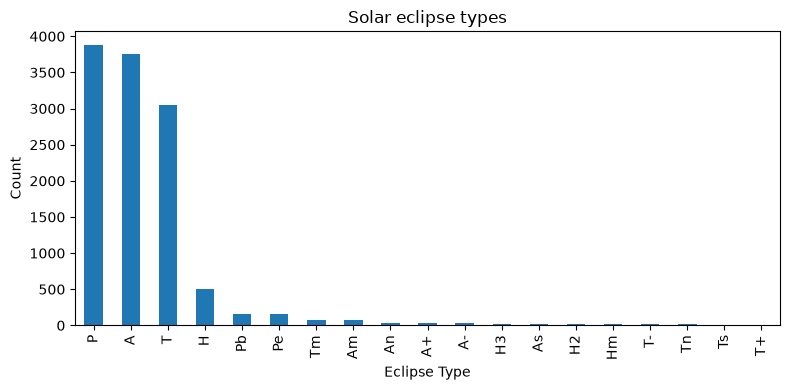

In [12]:
counts = solar["Eclipse Type"].value_counts()
counts.plot(kind="bar", figsize=(8, 4), title="Solar eclipse types")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 5. Förmörkelser över tid (per århundrade)

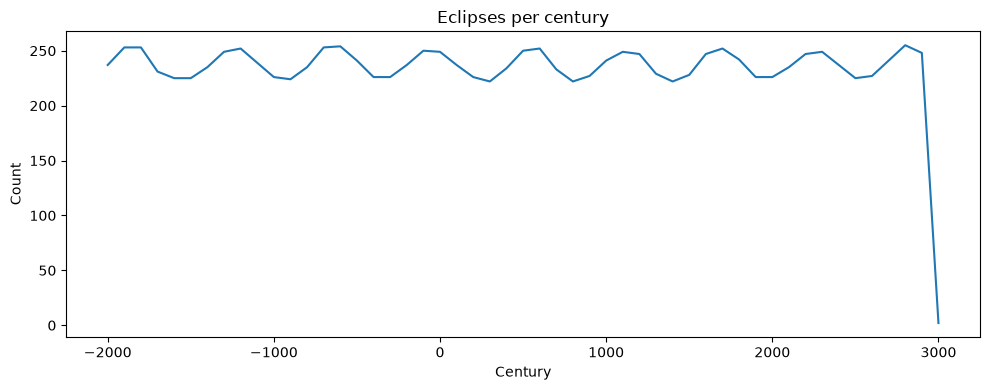

In [13]:
def parse_year(date_str):
    return int(date_str.split(" ")[0])

solar["Year"] = solar["Calendar Date"].apply(parse_year)
solar["Century"] = (solar["Year"] // 100) * 100

solar.groupby("Century").size().plot(kind="line", figsize=(10, 4), title="Eclipses per century")
plt.ylabel("Count")
plt.xlabel("Century")
plt.tight_layout()
plt.show()

## 6. Highlight: totala solförmörkelsen 12 augusti 2026

In [14]:
solar[solar["Calendar Date"].str.contains("2026")]

,Catalog Number,Calendar Date,Eclipse Time,Delta T (s),Lunation Number,Saros Number,Eclipse Type,Gamma,Eclipse Magnitude,Latitude,Longitude,Sun Altitude,Sun Azimuth,Path Width (km),Central Duration,Year,Century
9564,9565,2026 February 17,12:13:06,75,323,121,A,-0.9743,0.9630,64.7S,86.8E,12,268,616,02m20s,2026,2000
9565,9566,2026 August 12,17:47:06,75,329,126,T,0.8977,1.0386,65.2N,25.2W,26,248,294,02m18s,2026,2000


## 7. Vad jag lärde mig av datat

- Datumet står som text, typ "2026 August 12", så jag behöver dela upp det för att kunna filtrera på år.
- Latitude och longitude är inte vanliga siffror, utan text som "24S" eller "22W". Måste fixa det innan jag kan visa punkterna på en karta.
- Vissa kolumner har ett streck (-) istället för ett tomt värde, när förmörkelsen inte har någon central fas. Bra att veta innan jag bygger API:et.
- Datat är inte så stort, runt 12 000 rader, så jag kan bara läsa in allt i minnet. Behöver ingen databas.
- Förmörkelsen 12 augusti 2026 finns med i datat, så den tänkte jag lyfta fram extra i dashboarden.